# Parcial 3
jesus D serpa P


In [ ]:
!pip install lmfit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.9/98.9 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 3.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from lmfit.models import GaussianModel

In [ ]:
url = 'https://raw.githubusercontent.com/jesuserpajaro/Udea/main/vel.txt'
vel=np.loadtxt(url)/1000 # v_LOS in km s^-1

In [ ]:
url1 = 'https://raw.githubusercontent.com/jesuserpajaro/Udea/main/21cmsurvey_full.txt'
data=np.loadtxt(url1)



a) Determinación de la distancia $R$ en el plano galáctico

Consideraciones iniciales

Consideremos el escenario en el plano galáctico, es decir, para $b = 0$. En este caso, tanto la velocidad del Sol, denotada como $v_\odot$, como la velocidad del objeto en la línea de visión tienen componentes únicamente en este plano.

Relación entre las velocidades

La velocidad radial, medida desde la Tierra, se denomina $v_{\text{LOS}}$. Esta velocidad está relacionada con las velocidades del Sol y del objeto a lo largo de la línea de visión. Suponiendo que estas velocidades son exclusivamente resultado de la rotación galáctica, podemos expresar la componente de la velocidad del objeto en la línea de visión como:

\begin{equation}
v_{\text{obj}} = v_\odot \frac{R_o}{R}
\end{equation}

Aquí, $R_o$ representa la distancia del Sol al centro galáctico, y $R$ es la distancia del objeto al mismo centro.

Cálculo de la velocidad relativa

La velocidad radial medida, $v_{\text{LOS}}$, puede expresarse como la diferencia entre la componente de la velocidad del objeto en la línea de visión y la velocidad del Sol proyectada en la misma dirección:

\begin{equation}
v_{\text{LOS}} = v_{\text{obj}} \sin{l} - v_\odot \sin{l}
\end{equation}

Donde $l$ es la longitud galáctica, que define la dirección en la que se mide la velocidad.

Sustitución de $v_{\text{obj}}$

Sustituyendo la expresión de $v_{\text{obj}}$ en la ecuación de $v_{\text{LOS}}$, obtenemos:

\begin{equation}
v_{\text{LOS}} = v_\odot \frac{R_o}{R} \sin{l} - v_\odot \sin{l}
\end{equation}

Despeje de la distancia $R$

Finalmente, podemos despejar $R$ de la ecuación anterior para obtener una expresión que nos permita calcular la distancia del objeto al centro galáctico:

\begin{equation}
R = R_o \frac{v_\odot \sin l}{v_{\text{LOS}} + v_\odot \sin l}
\end{equation}

Esta ecuación nos permite determinar $R$ en función de las velocidades conocidas y la longitud galáctica.




b)Ajuste una funci ́on gaussiana para el pico principal (correspondiente a la emisi ́on de gas en el brazo

de Perseo) para cada una de las longitudes, considerando  ́unicamente las velocidades comprendi-
das entre -15 y -50 km/s. Haga tres gr ́aficas (correspondientes al valor m ́ınimo, medio, y m ́aximo de

longitud gal ́actica) que muestren que su ajuste de los espectros a funciones gaussianas es razonable.

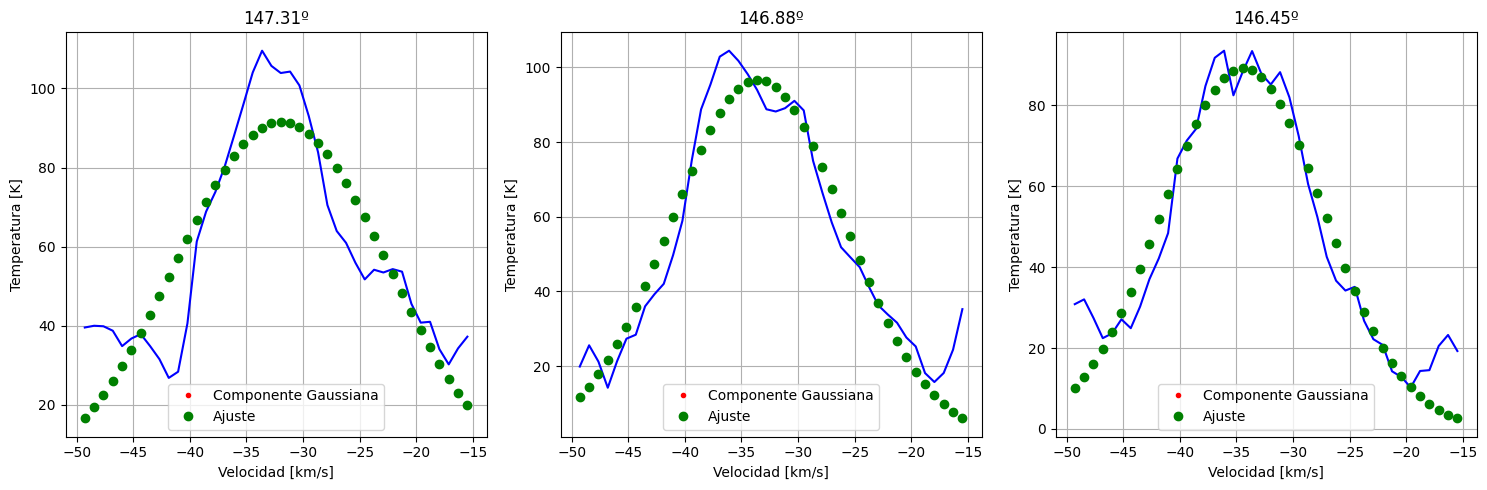

In [ ]:

def gaussian(x, amplitude, mean, stddev):
    return amplitude * np.exp(-((x - mean) ** 2) / (2.0 * stddev ** 2))

# Datos de entrada
longitudes = data[0]  # Longitudes en grados
espectros = data[1:]  # Espectros de temperatura de brillo (K)

# Índices correspondientes a las longitudes galácticas máxima, media y mínima
indices = [0, len(data) // 2, len(data) - 1]

# Crear una figura con subplots
fig, axs = plt.subplots(1, len(indices), figsize=(15, 5))

# Iteración sobre las longitudes seleccionadas
for idx, i in enumerate(indices):
    velocidad = vel
    brillo = espectros[:, i]

    # Filtrar el rango de velocidades entre -50 y -15 km/s
    filtro = (velocidad >= -50) & (velocidad <= -15)
    vel_filtrada = velocidad[filtro]
    brillo_filtrado = brillo[filtro]

    # Configuración y ajuste del modelo Gaussiano
    modelo_gaussiano = GaussianModel(prefix='gauss_')
    parametros = modelo_gaussiano.make_params(center=-30, sigma=2, amplitude=1000)
    parametros['gauss_center'].set(min=-50, max=-15)
    parametros['gauss_sigma'].set(min=1, max=10)
    parametros['gauss_amplitude'].set(min=20, max=3000)

    ajuste = modelo_gaussiano.fit(brillo_filtrado, parametros, x=vel_filtrada)
    componentes = ajuste.eval_components(x=vel_filtrada)

    # Visualización del ajuste en el subplot correspondiente
    axs[idx].plot(vel_filtrada, brillo_filtrado, 'b')
    axs[idx].plot(vel_filtrada, componentes['gauss_'], 'r.', label='Componente Gaussiana')
    axs[idx].plot(vel_filtrada, ajuste.best_fit, 'go', label='Ajuste')
    axs[idx].set_title(f'{longitudes[i]:.2f}º')
    axs[idx].set_xlabel('Velocidad [km/s]')
    axs[idx].set_ylabel('Temperatura [K]')
    axs[idx].legend(loc='best')
    axs[idx].grid(True)

# Ajustar el espacio entre subplots
plt.tight_layout()
plt.show()


c Usando el centro (valor medio) de cada gaussiana, haga una gr ́afica de longitud gal ́actica l vs. R
(radio respecto al centro de la galaxia) para el brazo de Perseo. Incluya un intervalo de confianza (2σ)
para R para cada longitud a partir de la varianza de cada gaussiana.

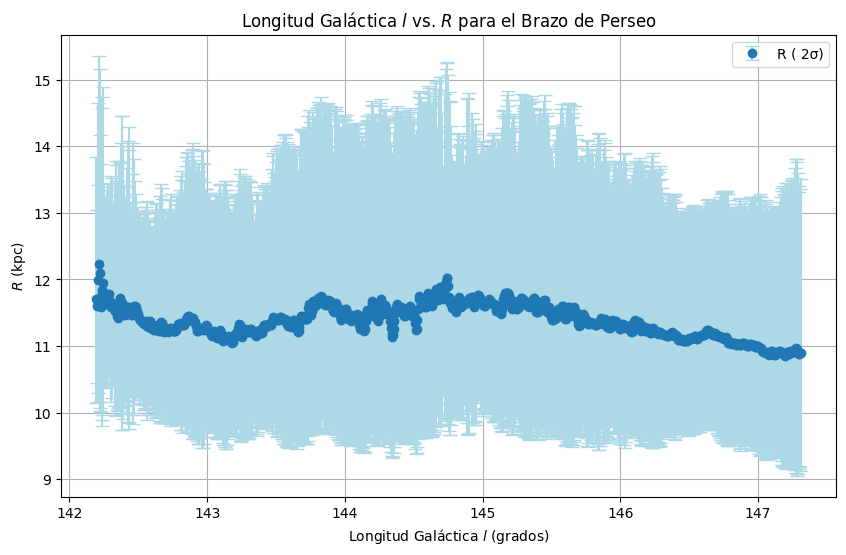

In [ ]:

# Datos de entrada
longitudes = data[0]  # Longitudes en grados
espectros = data[1:]  # Espectros de temperatura de brillo (K)
velocidad = vel  # Velocidades en km/s

# Conversión de longitudes a radianes
lons = longitudes * np.pi / 180  # radianes

# Constantes
v_sun = 239  # km/s
R_0 = 8.2  # Distancia del Sol al centro de la galaxia en kpc

# Inicialización de arrays para almacenar resultados
centros = np.zeros_like(longitudes)
sigmas = np.zeros_like(longitudes)
Rs = np.zeros_like(longitudes)

# Iteración sobre todas las longitudes galácticas
for i in range(len(longitudes)):
    x = velocidad
    y = espectros[:, i]

    # Filtrar el rango de velocidades entre -50 y -15 km/s
    filtro = (x >= -50) & (x <= -15)
    x_filtrado = x[filtro]
    y_filtrado = y[filtro]

    # Configuración y ajuste del modelo Gaussiano
    modelo_gaussiano = GaussianModel(prefix='gauss_')
    parametros = modelo_gaussiano.make_params(center=-30, sigma=2, amplitude=1000)
    parametros['gauss_center'].set(min=-50, max=-15)
    parametros['gauss_sigma'].set(min=1, max=10)
    parametros['gauss_amplitude'].set(min=20, max=3000)

    ajuste = modelo_gaussiano.fit(y_filtrado, parametros, x=x_filtrado)

    # Extraer el centro y la desviación estándar de la gaussiana
    centro = ajuste.params['gauss_center'].value
    sigma = ajuste.params['gauss_sigma'].value

    # Calcular el radio R
    R = R_0 * (v_sun * np.sin(lons[i])) / (centro + v_sun * np.sin(lons[i]))

    # Guardar los resultados
    centros[i] = centro
    sigmas[i] = sigma
    Rs[i] = R

# Calcular los intervalos de confianza 2σ
R_lower = R_0 * (v_sun * np.sin(lons)) / (centros + 2 * sigmas + v_sun * np.sin(lons))
R_upper = R_0 * (v_sun * np.sin(lons)) / (centros - 2 * sigmas + v_sun * np.sin(lons))

# Crear la gráfica de longitud galáctica vs R
plt.figure(figsize=(10, 6))
plt.errorbar(longitudes, Rs, yerr=[Rs - R_lower, R_upper - Rs], fmt='o', ecolor='lightblue', capsize=5, label='R ( 2σ)')
plt.xlabel('Longitud Galáctica $l$ (grados)')
plt.ylabel('$R$ (kpc)')
plt.title('Longitud Galáctica $l$ vs. $R$ para el Brazo de Perseo')
plt.legend()
plt.grid()
plt.show()
